<a href="https://colab.research.google.com/github/varthanharsh35-ux/24ADI003_24BAD033/blob/main/EX09_SCENARIO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
# Load datasets
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')

print('ratings shape:', ratings.shape)
print('movies  shape:', movies.shape)
print('tags    shape:', tags.shape)

ratings shape: (100836, 4)
movies  shape: (9742, 3)
tags    shape: (3683, 4)


In [ ]:
print('=== Ratings Sample ===')
display(ratings.head())

print('\n=== Movies Sample ===')
display(movies.head())

print('\n=== Ratings Info ===')
ratings.info()

=== Ratings Sample ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== Movies Sample ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



=== Ratings Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
print('Null values in ratings:')
print(ratings.isnull().sum())

print('\nRating distribution:')
print(ratings['rating'].describe())

print(f'\nTotal unique users : {ratings["userId"].nunique()}')
print(f'Total unique movies: {ratings["movieId"].nunique()}')

Null values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Rating distribution:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Total unique users : 610
Total unique movies: 9724


In [ ]:
# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Merge with movie titles
ratings_movies = ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')

# Keep only users with ≥ 20 ratings and movies with ≥ 10 ratings (reduce sparsity)
user_counts  = ratings_movies['userId'].value_counts()
movie_counts = ratings_movies['movieId'].value_counts()

active_users  = user_counts[user_counts  >= 20].index
active_movies = movie_counts[movie_counts >= 10].index

filtered = ratings_movies[
    ratings_movies['userId'].isin(active_users) &
    ratings_movies['movieId'].isin(active_movies)
]

print(f'Filtered dataset shape : {filtered.shape}')
print(f'Active users           : {filtered["userId"].nunique()}')
print(f'Active movies          : {filtered["movieId"].nunique()}')

Filtered dataset shape : (81116, 6)
Active users           : 610
Active movies          : 2269


In [ ]:
user_item_matrix = filtered.pivot_table(
    index='userId', columns='title', values='rating'
)

print('User-Item Matrix shape:', user_item_matrix.shape)
display(user_item_matrix.iloc[:5, :6])

User-Item Matrix shape: (610, 2269)


title,"'burbs, The (1989)",(500) Days of Summer (2009),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996)
userId,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calculate sparsity
total_cells   = user_item_matrix.shape[0] * user_item_matrix.shape[1]
missing_cells = user_item_matrix.isnull().sum().sum()
sparsity      = (missing_cells / total_cells) * 100

print(f'Total cells    : {total_cells:,}')
print(f'Missing cells  : {missing_cells:,}')
print(f'Sparsity       : {sparsity:.2f}%')

# Fill missing values with 0 (unrated)
user_item_filled = user_item_matrix.fillna(0)
print('\nMissing values after fill:', user_item_filled.isnull().sum().sum())

Total cells    : 1,384,090
Missing cells  : 1,302,974
Sparsity       : 94.14%

Missing values after fill: 0


In [ ]:
user_similarity_matrix = cosine_similarity(user_item_filled)
user_similarity_df     = pd.DataFrame(
    user_similarity_matrix,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print('User Similarity Matrix shape:', user_similarity_df.shape)
display(user_similarity_df.iloc[:5, :5])

User Similarity Matrix shape: (610, 610)


userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.029977,0.115634,0.220630,0.134869
2,0.029977,1.000000,0.000000,0.004256,0.017471
3,0.115634,0.000000,1.000000,0.004532,0.009302
4,0.220630,0.004256,0.004532,1.000000,0.139754
5,0.134869,0.017471,0.009302,0.139754,1.000000


In [ ]:
def get_top_n_similar_users(user_id, similarity_df, n=10):
    """Return top-N most similar users for a given user_id."""
    sim_scores = similarity_df[user_id].drop(index=user_id)
    return sim_scores.nlargest(n)

# Example: top 10 users similar to user 1
TARGET_USER = user_item_filled.index[0]
top_similar = get_top_n_similar_users(TARGET_USER, user_similarity_df, n=10)

print(f'Top 10 users similar to User {TARGET_USER}:')
print(top_similar)

Top 10 users similar to User 1:
userId
368    0.393441
313    0.386130
91     0.380619
266    0.379847
57     0.374995
288    0.374261
217    0.372970
19     0.370308
469    0.368074
599    0.366603
Name: 1, dtype: float64


In [ ]:
def predict_rating(user_id, movie_title, user_item_matrix, similarity_df, n=10):
    """Predict a user's rating for a movie using weighted average of similar users."""
    if movie_title not in user_item_matrix.columns:
        return np.nan

    similar_users = get_top_n_similar_users(user_id, similarity_df, n=n)
    sim_users_ids = similar_users.index

    # Ratings given by similar users
    sim_ratings = user_item_matrix.loc[sim_users_ids, movie_title]
    sim_scores  = similar_users

    # Only consider users who have rated the movie
    mask        = sim_ratings != 0
    sim_ratings = sim_ratings[mask]
    sim_scores  = sim_scores[mask]

    if sim_scores.sum() == 0 or len(sim_scores) == 0:
        return user_item_matrix.replace(0, np.nan).loc[user_id].mean()

    return np.dot(sim_scores, sim_ratings) / sim_scores.sum()


def recommend_movies(user_id, user_item_matrix, similarity_df, n_similar=10, top_n=10):
    """Generate top-N movie recommendations for a user."""
    # Movies the user hasn't rated yet
    user_ratings   = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()

    predictions = {}
    for movie in unrated_movies:
        pred = predict_rating(user_id, movie, user_item_matrix, similarity_df, n=n_similar)
        if not np.isnan(pred):
            predictions[movie] = pred

    sorted_preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    return sorted_preds[:top_n]


recommendations = recommend_movies(TARGET_USER, user_item_filled, user_similarity_df, top_n=10)

print(f'\nTop 10 Recommendations for User {TARGET_USER}:')
rec_df = pd.DataFrame(recommendations, columns=['Movie', 'Predicted Rating'])
rec_df.index += 1
display(rec_df)


Top 10 Recommendations for User 1:


,Movie,Predicted Rating
1,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",5.0
2,"Big Sleep, The (1946)",5.0
3,Doctor Zhivago (1965),5.0
4,Empire Records (1995),5.0
5,In Bruges (2008),5.0
6,Little Big Man (1970),5.0
7,Once Upon a Time in America (1984),5.0
8,Papillon (1973),5.0
9,Paths of Glory (1957),5.0
10,"Ref, The (1994)",5.0


In [ ]:
# Show recommendations for 3 different users
sample_users = list(user_item_filled.index[:3])

for uid in sample_users:
    recs = recommend_movies(uid, user_item_filled, user_similarity_df, top_n=5)
    print(f'\n--- User {uid} – Top 5 Recommendations ---')
    for rank, (movie, score) in enumerate(recs, 1):
        print(f'  {rank}. {movie[:60]:60s}  (pred: {score:.2f})')


--- User 1 – Top 5 Recommendations ---
  1. Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)          (pred: 5.00)
  2. Big Sleep, The (1946)                                         (pred: 5.00)
  3. Doctor Zhivago (1965)                                         (pred: 5.00)
  4. Empire Records (1995)                                         (pred: 5.00)
  5. In Bruges (2008)                                              (pred: 5.00)

--- User 2 – Top 5 Recommendations ---
  1. 40-Year-Old Virgin, The (2005)                                (pred: 5.00)
  2. 8 Mile (2002)                                                 (pred: 5.00)
  3. Alien (1979)                                                  (pred: 5.00)
  4. Anchorman: The Legend of Ron Burgundy (2004)                  (pred: 5.00)
  5. Armageddon (1998)                                             (pred: 5.00)

--- User 3 – Top 5 Recommendations ---
  1. Army of Darkness (1993)                                       (pred: 5.00)


In [ ]:
# Train-test split on the ratings dataframe
train_data, test_data = train_test_split(filtered, test_size=0.2, random_state=42)

# Rebuild user-item matrix on training data only
train_matrix = train_data.pivot_table(
    index='userId', columns='title', values='rating'
).fillna(0)

train_similarity = pd.DataFrame(
    cosine_similarity(train_matrix),
    index=train_matrix.index,
    columns=train_matrix.index
)

print('Train matrix built. Running evaluation on test set (sample of 200 rows)...')

# Sample to keep it fast
test_sample = test_data.sample(min(200, len(test_data)), random_state=42)

actuals, predicted = [], []
for _, row in test_sample.iterrows():
    uid   = row['userId']
    title = row['title']
    actual_rating = row['rating']

    if uid not in train_matrix.index:
        continue

    pred = predict_rating(uid, title, train_matrix, train_similarity, n=10)
    if not np.isnan(pred):
        actuals.append(actual_rating)
        predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actuals, predicted))
mae  = mean_absolute_error(actuals, predicted)

print(f'\nEvaluation Results (n={len(actuals)} samples):')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')

Train matrix built. Running evaluation on test set (sample of 200 rows)...

Evaluation Results (n=200 samples):
  RMSE : 0.9347
  MAE  : 0.6922


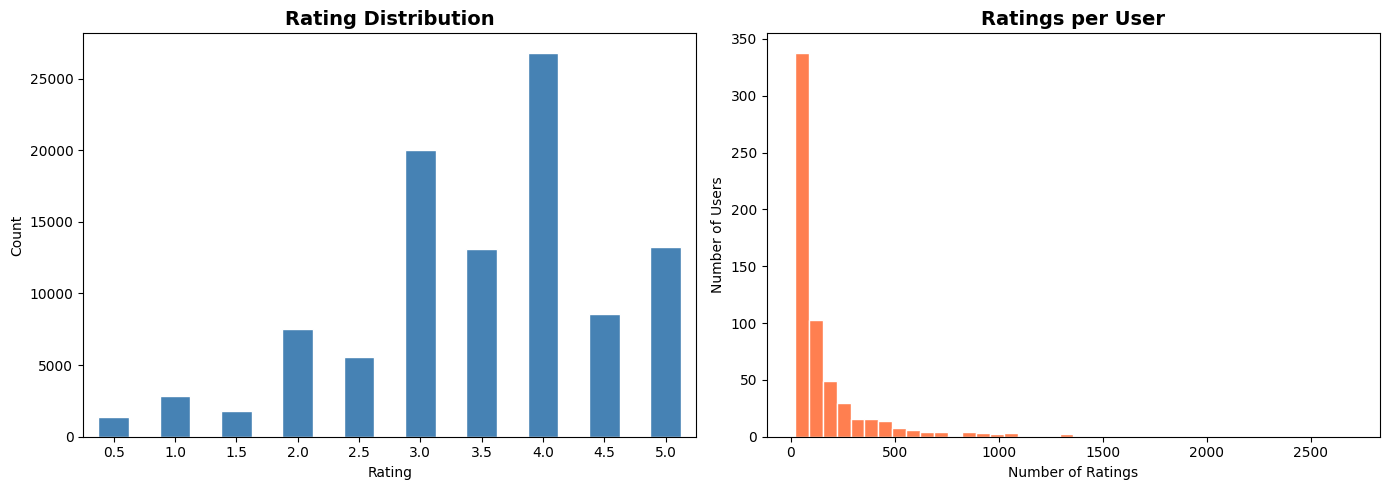

In [ ]:
# ── 1. Rating Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Ratings per user distribution
user_rating_counts = ratings.groupby('userId')['rating'].count()
axes[1].hist(user_rating_counts, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

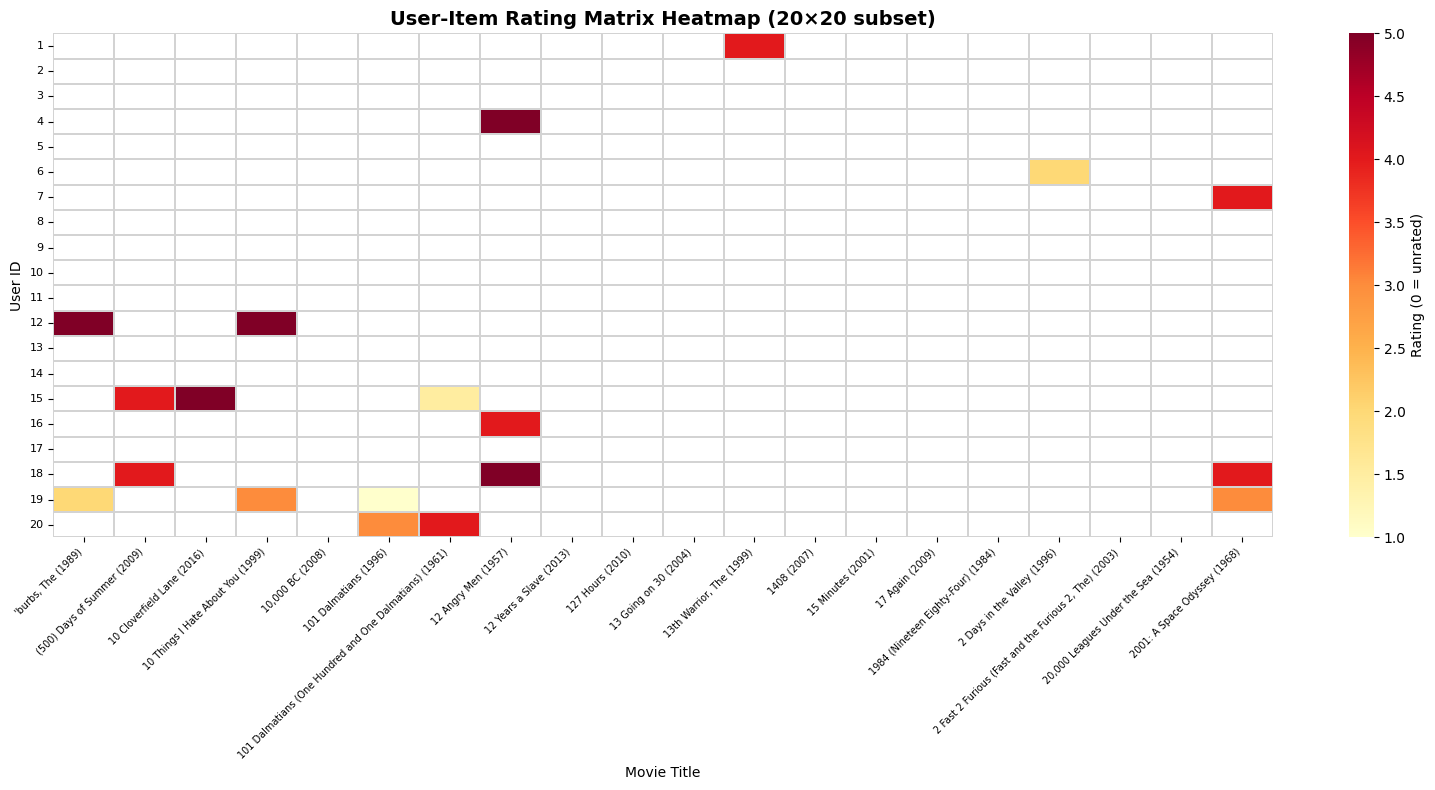

In [ ]:
# ── 2. Heatmap of User-Item Matrix (subset) ─────────────────────────────────
subset = user_item_matrix.iloc[:20, :20]

plt.figure(figsize=(16, 8))
sns.heatmap(
    subset,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='lightgrey',
    annot=False,
    cbar_kws={'label': 'Rating (0 = unrated)'}
)
plt.title('User-Item Rating Matrix Heatmap (20×20 subset)', fontsize=14, fontweight='bold')
plt.xlabel('Movie Title')
plt.ylabel('User ID')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('user_item_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

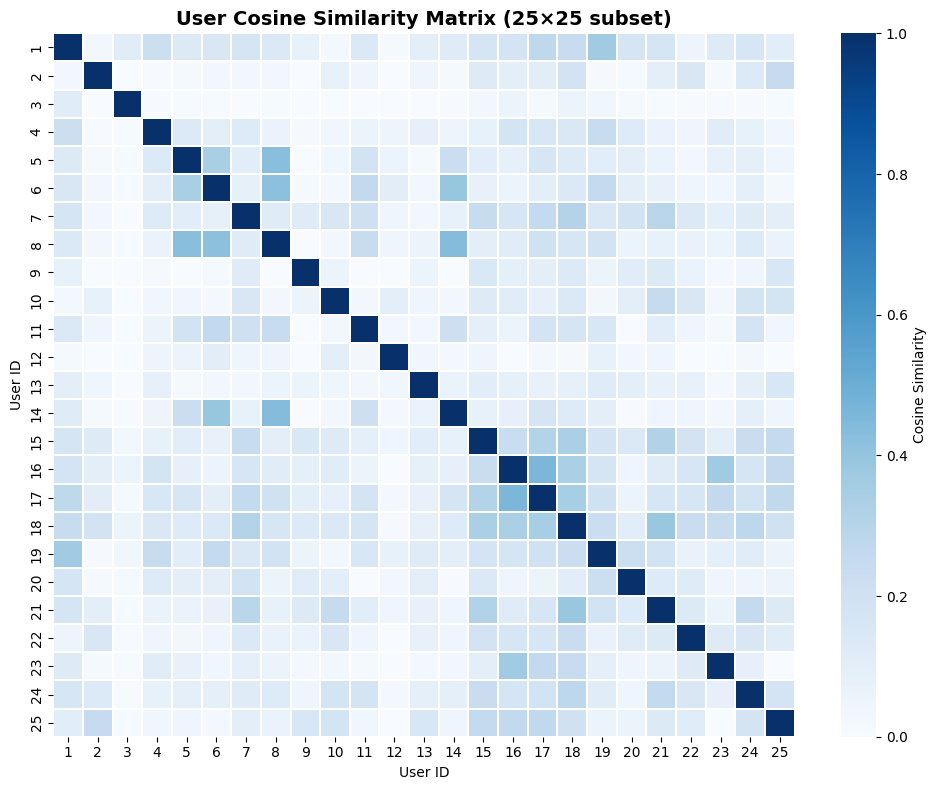

In [ ]:
# ── 3. User Similarity Matrix Heatmap (subset) ──────────────────────────────
sim_subset = user_similarity_df.iloc[:25, :25]

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_subset,
    cmap='Blues',
    linewidths=0.2,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('User Cosine Similarity Matrix (25×25 subset)', fontsize=14, fontweight='bold')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.savefig('user_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

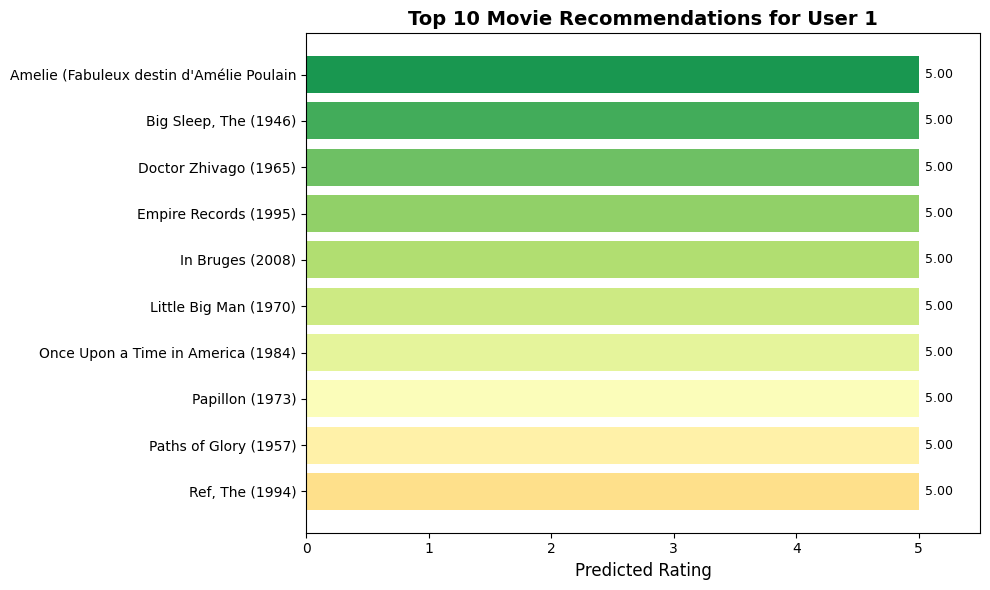

In [ ]:
# ── 4. Top Recommended Movies for Target User ────────────────────────────────
if recommendations:
    top_movies  = [r[0][:40] for r in recommendations[:10]]
    top_scores  = [r[1]       for r in recommendations[:10]]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_movies[::-1], top_scores[::-1],
                   color=plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(top_movies))))
    ax.set_xlabel('Predicted Rating', fontsize=12)
    ax.set_title(f'Top 10 Movie Recommendations for User {TARGET_USER}',
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, 5.5)
    for bar, score in zip(bars, top_scores[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{score:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('top_recommendations_user.png', dpi=150, bbox_inches='tight')
    plt.show()

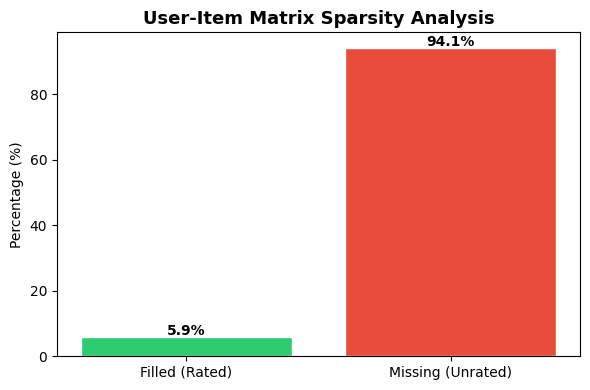

Matrix sparsity: 94.14%
This is typical for collaborative filtering datasets.


In [ ]:
# ── 5. Sparsity Visual ──────────────────────────────────────────────────────
filled_pct  = 100 - sparsity

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Filled (Rated)', 'Missing (Unrated)'], [filled_pct, sparsity],
       color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('User-Item Matrix Sparsity Analysis', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
for i, v in enumerate([filled_pct, sparsity]):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sparsity_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrix sparsity: {sparsity:.2f}%')
print(f'This is typical for collaborative filtering datasets.')